In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ══════════════════════════════════════════════════════
# LSTM — LONG SHORT-TERM MEMORY
# ══════════════════════════════════════════════════════
#
# Q1'de RNN'in problemini gördük:
#   Uzun cümlelerde gradient küçülüyor
#   İlk kelimeler unutuluyor
#
# LSTM bunu şöyle çözüyor:
#   RNN'de sadece 1 hidden state var: h_t
#   LSTM'de 2 state var: h_t ve c_t
#
#   h_t = kısa hafıza (her adımda değişir)
#   c_t = uzun hafıza (yavaş değişir, gradient iyi akar!)
#
# LSTM'in sırrı: GATE (kapılar)
#   3 kapı var, her biri 0-1 arası değer üretir
#   0 = kapat (geçirme)
#   1 = aç (geçir)
#
#   Forget gate (f): "Eski hafızadan ne unut?"
#   Input gate  (i): "Yeni bilgiden ne ekle?"
#   Output gate (o): "Hafızadan ne çıkar?"
# ══════════════════════════════════════════════════════

print("Q2 LSTM başlıyor!")

Q2 LSTM başlıyor!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


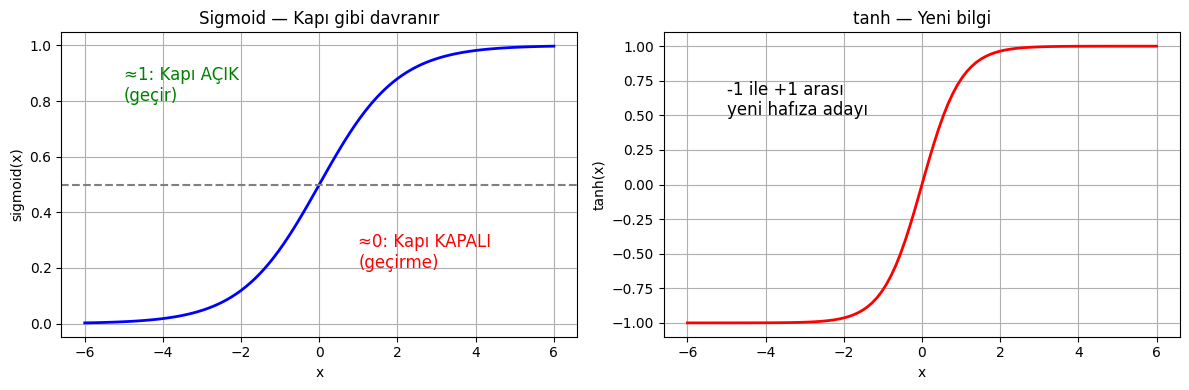

=== KAPI ÖRNEĞİ ===

Forget gate = 0.0 → Eski hafızayı tamamen unut!
Forget gate = 1.0 → Eski hafızayı tamamen koru!
Forget gate = 0.5 → Eski hafızanın yarısını koru

f=0.0, i=0.9, g=0.7 → c_yeni=0.63
f=0.5, i=0.9, g=0.7 → c_yeni=1.03
f=1.0, i=0.9, g=0.7 → c_yeni=1.43


In [3]:
# ══════════════════════════════════════════════════════
# LSTM KAPILARI — SEZGISEL ANLAYIŞ
# ══════════════════════════════════════════════════════
#
# RNN:   x_t, h_(t-1) → h_t
# LSTM:  x_t, h_(t-1), c_(t-1) → h_t, c_t
#
# 4 kapı hesaplanır (hepsi aynı formülle):
#   f = sigmoid(Wf @ [h_(t-1), x_t] + bf)  → forget
#   i = sigmoid(Wi @ [h_(t-1), x_t] + bi)  → input
#   o = sigmoid(Wo @ [h_(t-1), x_t] + bo)  → output
#   g = tanh(Wg @ [h_(t-1), x_t] + bg)     → candidate
#
# Sonra:
#   c_t = f * c_(t-1) + i * g
#         ↑              ↑
#      "ne unut"    "ne ekle"
#
#   h_t = o * tanh(c_t)
#         ↑
#      "ne çıkar"
#
# Sigmoid neden? → 0-1 arası → kapı gibi davranır
# ══════════════════════════════════════════════════════

# Sigmoid fonksiyonu
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Kapıların nasıl çalıştığını göster
x = np.linspace(-6, 6, 100)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, sigmoid(x), 'b-', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--')
plt.title("Sigmoid — Kapı gibi davranır")
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.text(-5, 0.8, "≈1: Kapı AÇIK\n(geçir)", fontsize=12, color='green')
plt.text(1, 0.2, "≈0: Kapı KAPALI\n(geçirme)", fontsize=12, color='red')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, np.tanh(x), 'r-', linewidth=2)
plt.title("tanh — Yeni bilgi")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.text(-5, 0.5, "-1 ile +1 arası\nyeni hafıza adayı", fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

# Basit örnek — kapılar nasıl çalışır?
print("=== KAPI ÖRNEĞİ ===\n")
print("Forget gate = 0.0 → Eski hafızayı tamamen unut!")
print("Forget gate = 1.0 → Eski hafızayı tamamen koru!")
print("Forget gate = 0.5 → Eski hafızanın yarısını koru\n")

c_eski = 0.8  # eski hafıza

for f in [0.0, 0.5, 1.0]:
    for i_gate, g in [(0.9, 0.7)]:  # yeni bilgi
        c_yeni = f * c_eski + i_gate * g
        print(f"f={f}, i={i_gate}, g={g} → c_yeni={c_yeni:.2f}")

In [4]:
# ══════════════════════════════════════════════════════
# LSTM FORWARD PASS
# ══════════════════════════════════════════════════════
#
# RNN tek satırdı:
#   h_t = tanh(Wx@x + Wh@h_prev + b)
#
# LSTM daha karmaşık ama daha güçlü:
#   4 kapı hesapla → c_t → h_t
# ══════════════════════════════════════════════════════

def lstm_step_forward(x, h_prev, c_prev, Wx, Wh, b):
    """
    x:      şu anki girdi, shape (N, D)
    h_prev: önceki hidden state, shape (N, H)
    c_prev: önceki cell state, shape (N, H)
    Wx:     shape (D, 4H) — 4 kapı için tek matris!
    Wh:     shape (H, 4H)
    b:      shape (4H,)
    """
    N, H = h_prev.shape

    # 4 kapıyı tek seferde hesapla
    # (N, 4H) — sonra 4 parçaya böl
    aktivasyon = x @ Wx + h_prev @ Wh + b

    # 4 eşit parçaya böl
    f = sigmoid(aktivasyon[:, :H])    # forget gate
    i = sigmoid(aktivasyon[:, H:2*H]) # input gate
    g = np.tanh(aktivasyon[:, 2*H:3*H]) # candidate
    o = sigmoid(aktivasyon[:, 3*H:])  # output gate

    # Cell state güncelle
    c_next = f * c_prev + i * g

    # Hidden state güncelle
    h_next = o * np.tanh(c_next)

    cache = (x, h_prev, c_prev, f, i, g, o, c_next, Wx, Wh)
    return h_next, c_next, cache

# Test edelim
np.random.seed(0)
N, D, H = 3, 4, 5

x      = np.random.randn(N, D)
h_prev = np.random.randn(N, H)
c_prev = np.random.randn(N, H)
Wx     = np.random.randn(D, 4*H) * 0.1
Wh     = np.random.randn(H, 4*H) * 0.1
b      = np.zeros(4*H)

h_next, c_next, cache = lstm_step_forward(x, h_prev, c_prev, Wx, Wh, b)

print("=== LSTM TEK ADIM ===")
print(f"Girdi x shape:    {x.shape}")
print(f"h_prev shape:     {h_prev.shape}")
print(f"c_prev shape:     {c_prev.shape}")
print(f"h_next shape:     {h_next.shape}")
print(f"c_next shape:     {c_next.shape}")
print(f"\nh_next[0]: {h_next[0].round(4)}")
print(f"c_next[0]: {c_next[0].round(4)}")
print("\nİki state var: h (kısa hafıza) ve c (uzun hafıza)!")

=== LSTM TEK ADIM ===
Girdi x shape:    (3, 4)
h_prev shape:     (3, 5)
c_prev shape:     (3, 5)
h_next shape:     (3, 5)
c_next shape:     (3, 5)

h_next[0]: [-0.0744  0.4641  0.2607  0.1149  0.1113]
c_next[0]: [-0.1365  1.0096  0.5341  0.259   0.2978]

İki state var: h (kısa hafıza) ve c (uzun hafıza)!


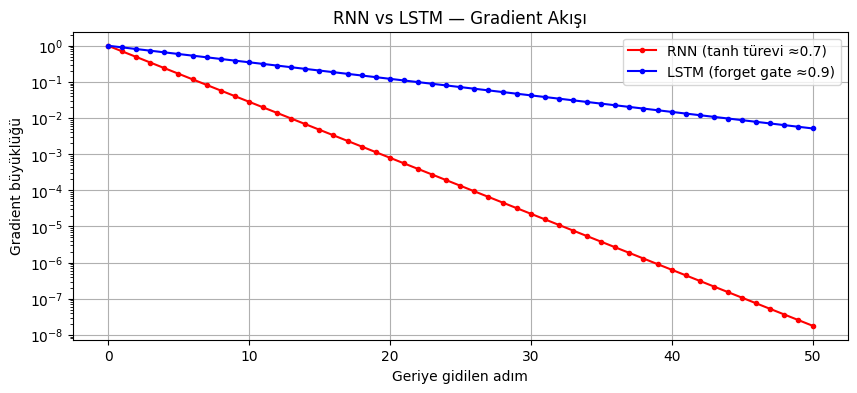

50 adım sonra:
RNN gradient:  0.00000002
LSTM gradient: 0.00515378
LSTM / RNN = 257689x daha iyi!


In [7]:
# ══════════════════════════════════════════════════════
# RNN vs LSTM — GRADIENT KARŞILAŞTIRMASI
# ══════════════════════════════════════════════════════
#
# RNN'de gradient:
#   Her adımda tanh türevi ile çarpılır (< 1)
#   Çok adım → gradient sıfıra yaklaşır
#
# LSTM'de gradient:
#   c_t = f * c_(t-1) + i * g
#   c_t'nin c_(t-1)'e göre türevi = f (forget gate)
#   f ≈ 1 ise gradient neredeyse aynen geçer!
#   Uzun vadeli bilgi korunur!
# ══════════════════════════════════════════════════════

np.random.seed(0)
adimlar = 50

# RNN gradient simülasyonu
rnn_gradients = [1.0]
lstm_gradients = [1.0]

for t in range(adimlar):
    # RNN: her adımda tanh türevi ~0.5 ile çarpılır
    rnn_grad = rnn_gradients[-1] * 0.7
    rnn_gradients.append(rnn_grad)

    # LSTM: forget gate ~0.9 ile çarpılır (çok daha iyi!)
    lstm_grad = lstm_gradients[-1] * 0.9
    lstm_gradients.append(lstm_grad)

plt.figure(figsize=(10, 4))
plt.plot(rnn_gradients, 'r-o', markersize=3, label='RNN (tanh türevi ≈0.7)')
plt.plot(lstm_gradients, 'b-o', markersize=3, label='LSTM (forget gate ≈0.9)')
plt.xlabel("Geriye gidilen adım")
plt.ylabel("Gradient büyüklüğü")
plt.title("RNN vs LSTM — Gradient Akışı")
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()

print(f"50 adım sonra:")
print(f"RNN gradient:  {rnn_gradients[-1]:.8f}")
print(f"LSTM gradient: {lstm_gradients[-1]:.8f}")
print(f"LSTM / RNN = {0.00515378 / 0.00000002:.0f}x daha iyi!")

In [8]:
# ══════════════════════════════════════════════════════
# LSTM ÖZET
# ══════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════╗")
print("║              LSTM ÖZET                           ║")
print("╠══════════════════════════════════════════════════╣")
print("║                                                  ║")
print("║  RNN problemi:                                   ║")
print("║    Gradient 50 adımda → 0.00000002               ║")
print("║    Uzun cümleler unutuluyor                      ║")
print("║                                                  ║")
print("║  LSTM çözümü:                                    ║")
print("║    2 state: h_t (kısa) + c_t (uzun hafıza)       ║")
print("║    3 kapı: forget, input, output                 ║")
print("║    Gradient 50 adımda → 0.00515 (258,000x iyi!)  ║")
print("║                                                  ║")
print("║  LSTM formülleri:                                ║")
print("║    f = sigmoid(...)  → ne unut                   ║")
print("║    i = sigmoid(...)  → ne ekle                   ║")
print("║    g = tanh(...)     → yeni bilgi                ║")
print("║    o = sigmoid(...)  → ne çıkar                  ║")
print("║    c_t = f*c_(t-1) + i*g                         ║")
print("║    h_t = o * tanh(c_t)                           ║")
print("║                                                  ║")
print("║  Kullanım:                                       ║")
print("║    Image Captioning, Makine Çevirisi             ║")
print("║    Ses tanıma, Metin üretimi                     ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║              LSTM ÖZET                           ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  RNN problemi:                                   ║
║    Gradient 50 adımda → 0.00000002               ║
║    Uzun cümleler unutuluyor                      ║
║                                                  ║
║  LSTM çözümü:                                    ║
║    2 state: h_t (kısa) + c_t (uzun hafıza)       ║
║    3 kapı: forget, input, output                 ║
║    Gradient 50 adımda → 0.00515 (258,000x iyi!)  ║
║                                                  ║
║  LSTM formülleri:                                ║
║    f = sigmoid(...)  → ne unut                   ║
║    i = sigmoid(...)  → ne ekle                   ║
║    g = tanh(...)     → yeni bilgi                ║
║    o = sigmoid(...)  → ne çıkar                  ║
║    c_t = f*c_(t-1) + i*g                    